# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from typing import Union, List

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from core.variables import *

# $\max\{\mathrm{E}(X), 0\}$

## EDA

In [6]:
X = UnivariateGaussian(mean=0, std=1)
func = lambda x: max(x, 0)  # not differentiable

In [7]:
# population 
theta0 = X.mean
phi0 = func(theta0)
print('Population parameters: ', phi0)

Population parameters:  0


## Plugin Estiamte

Denote $\hat{\theta}_N = \mathrm{E}_{\hat{P}_N}(X)$, then the plugin estimator is written as:
$$
\phi(\hat{\theta}_N) = \max\{\hat{\theta}_N, 0\}
$$

In [8]:
# sample
sample_size = 1000
sample_arr = X.sample(sample_size)

# plugin estimate
theta_hat = np.mean(sample_arr)
phi_hat = func(theta_hat)

# empirical distribution of plugin estimate
emp_dist_arr = np.array([
    func(np.mean(X.sample(sample_size))) for _ in range(1000)
])

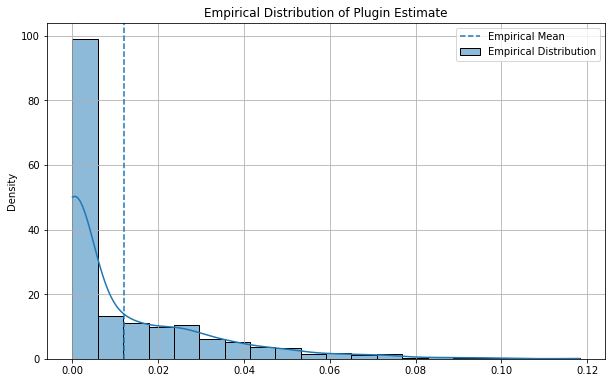

In [9]:
# visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
sns.histplot(emp_dist_arr, bins=20, kde=True, color='C0', stat='density', ax=ax, label='Empirical Distribution')
plt.axvline(emp_dist_arr.mean(), color='C0', linestyle='--', label='Empirical Mean')
plt.title('Empirical Distribution of Plugin Estimate')

plt.legend()
plt.grid()
plt.show()

## Nonparametric bootstrap

In [10]:
def create_nonparametric_bootstrap_sample(
    sample_arr: np.ndarray, n_bootstraps: int, boot_sample_size: int = None
) -> np.ndarray:
    """ 
    Create nonparametric bootstrap samples from the given sample array.

    Params:
    --------
    sample_arr: np.ndarray
        Array of samples from which bootstrap samples are to be created.
    n_bootstraps: int
        Number of bootstrap samples to be created.
    boot_sample_size: int
        Size of each bootstrap sample. If None, the size is the same as the original sample.

    Returns:
    --------
    np.ndarray
        Array of bootstrap samples. Shape: (n_bootstraps, boot_sample_size)
    """
    if boot_sample_size is None:
        boot_sample_size = sample_arr.shape[0]
    return np.random.choice(sample_arr, size=(n_bootstraps, boot_sample_size ), replace=True)

In [11]:
def nonparametric_bootstrap(
    sample_arr: np.ndarray, n_bootstraps: int, estimator: callable
) -> np.ndarray:
    """ 
    Perform nonparametric bootstrap on the given sample array.

    Params:
    --------
    sample_arr: np.ndarray
        Array of samples from which bootstrap samples are to be created.
    n_bootstraps: int
        Number of bootstrap samples to be created.
    estimator: callable
        Estimator function to be applied on each bootstrap sample.

    Returns:
    --------
    np.ndarray
        Array of bootstrap estimates. Shape: (n_bootstraps,)
    """
    boot_samples = create_nonparametric_bootstrap_sample(sample_arr, n_bootstraps)
    return np.array([estimator(boot_sample) for boot_sample in boot_samples])

In [12]:
# nonparametric bootstrap parameters
n_bootstraps = 1000

# nonparametric bootstrap
boot_param_dstn_arr = nonparametric_bootstrap(sample_arr, n_bootstraps, lambda x: func(np.mean(x)))

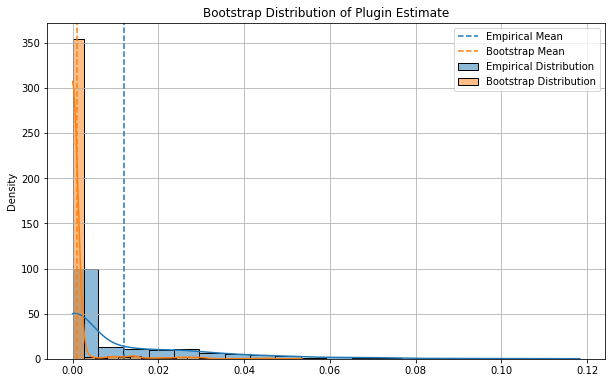

In [13]:
# visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical distribution of plugin estimate
sns.histplot(emp_dist_arr, bins=20, kde=True, color='C0', stat='density', ax=ax, label='Empirical Distribution')
plt.axvline(emp_dist_arr.mean(), color='C0', linestyle='--', label='Empirical Mean')


# bootstrap distribution of plugin estimate
sns.histplot(boot_param_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Bootstrap Distribution')
plt.axvline(boot_param_dstn_arr.mean(), color='C1', linestyle='--', label='Bootstrap Mean')
plt.title('Bootstrap Distribution of Plugin Estimate')

plt.legend()
plt.grid()
plt.show()

## m-out-of-n bootstrap

In [14]:
def m_of_of_n_bootstrap(sample_arr: np.ndarray, q: float, max_j: int, n_bootstraps: int, estimator: callable) -> np.ndarray:
    """ 
    Perform m-out-of-n bootstrap. This method follows (Bickle and Sakov 2008, Statistica Sinica).

    Params:
    --------
    sample_arr: np.ndarray
        Array of samples from which bootstrap samples are to be created.
    q: float
        parameter for generating the list of candidate m values.
    max_j: int
        maximum value of j for generating the list of candidate m values.
    n_bootstraps: int
        Number of bootstrap samples to be created.
    estimator: callable
        Estimator function that takes in a sample array and returns the estimate.

    Returns:
    --------
    np.ndarray
        Array of candidate m values.
    """
    # define the list of candidate m values
    m_list = np.array([int(q**j * sample_arr.shape[0]) for j in range(max_j)])
    m_boot_dstn_list = [None] * len(m_list)
    
    # compute bootstrap estimates for each candidate m value
    for m_idx, m in enumerate(m_list):
        # create bootstrap samples
        boot_sample_arr = create_nonparametric_bootstrap_sample(sample_arr, n_bootstraps=n_bootstraps, boot_sample_size=m)

        # compute bootstrap estimates
        m_boot_dstn_list[m_idx] = np.array([
            estimator(boot_sample) for boot_sample in boot_sample_arr
        ])

    # choose the best m
    discrepancy_list = [None] * (len(m_list) - 1)
    for idx, (prev_dstn, current_dstn) in enumerate(zip(m_boot_dstn_list[:-1], m_boot_dstn_list[1:])):
        ks_stat, _ = ks_2samp(prev_dstn, current_dstn)
        discrepancy_list[idx] = ks_stat

    min_discp_idx = np.argmin(discrepancy_list)
    return m_boot_dstn_list[min_discp_idx]

In [15]:
# m-out-of-n bootstrap parameters
n_bootstraps = 1000
q = 0.95
max_j = 50

# m-out-of-n bootstrap
mnb_param_dstn_arr = m_of_of_n_bootstrap(
    sample_arr, q=q, max_j=max_j, n_bootstraps=n_bootstraps, estimator=lambda x: func(x.mean())
)

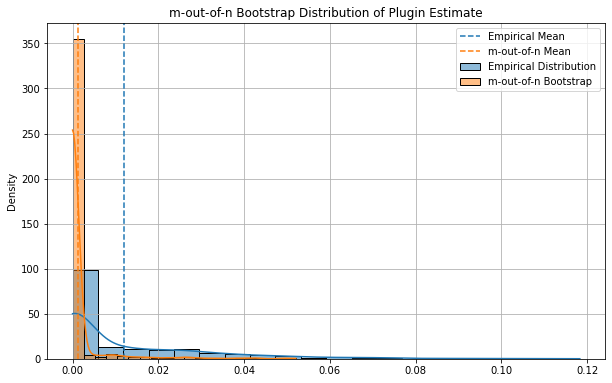

In [16]:
# visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical distribution of plugin estimate
sns.histplot(emp_dist_arr, bins=20, kde=True, color='C0', stat='density', ax=ax, label='Empirical Distribution')
plt.axvline(emp_dist_arr.mean(), color='C0', linestyle='--', label='Empirical Mean')

# bootstrap distribution of plugin estimate
sns.histplot(mnb_param_dstn_arr, bins=20, kde=True, stat='density', ax=ax, label='m-out-of-n Bootstrap', color='C1')
plt.axvline(mnb_param_dstn_arr.mean(), color='C1', linestyle='--', label='m-out-of-n Mean')
plt.title('m-out-of-n Bootstrap Distribution of Plugin Estimate')

plt.legend()
plt.grid()
plt.show()

## Numerical bootstrap

In [17]:
def numerical_bootstrap(
    sample_arr: np.ndarray, n_bootstraps: int, epsilon_n: int, estimator: callable
) -> np.ndarray:
    """ 
    Perform numerical bootstrap. This method follows (Hong and Li 2020, Annals of Statistics).
    
    Params:
    --------
    sample_arr: np.ndarray
        Array of samples from which bootstrap samples are to be created.
    n_bootstraps: int
        Number of bootstrap samples to be created.
    epsilon_n: int
        parameter 
    estimator: callable
        Estimator function that takes in a sample array and returns the estimate.
    """
    # calculate plugin estimate 
    plugin_est = estimator(sample_arr)

    # create bootstrap samples, shape = (n_bootstraps, sample_size)
    boot_sample_arr = create_nonparametric_bootstrap_sample(sample_arr, n_bootstraps=n_bootstraps)

    # construct centered bootstrap distribution of observations
    perturbed_sample_arr = np.array([
        np.sqrt(sample_arr.shape[0]) * (boot_sample - sample_arr) for boot_sample in boot_sample_arr
    ])  # shape = (n_bootstraps, sample_size)

    # compute parameter estimates for each bootstrap sample
    param_dstn_arr = np.array([
        estimator(sample_arr + epsilon_n * perturbed_sample) for perturbed_sample in perturbed_sample_arr
        ])
    
    return param_dstn_arr


In [18]:
# numerical bootstrap parameters
n_bootstraps = 1000
epsilon_n = 0.1

# numerical bootstrap
numb_param_dstn_arr = numerical_bootstrap(
    sample_arr, n_bootstraps=n_bootstraps, epsilon_n=epsilon_n, estimator=lambda x: func(x.mean())
)

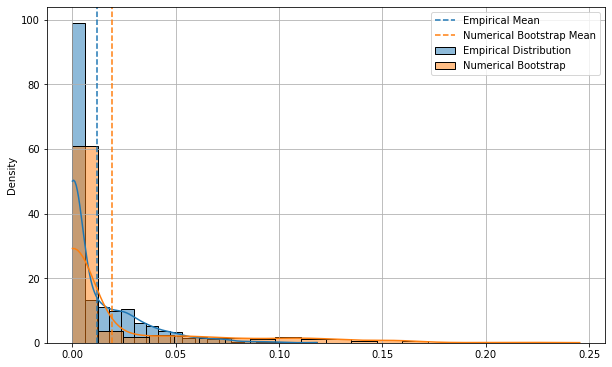

In [19]:
# visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical distribution of plugin estimate
sns.histplot(emp_dist_arr, bins=20, kde=True, color='C0', stat='density', ax=ax, label='Empirical Distribution')
plt.axvline(emp_dist_arr.mean(), color='C0', linestyle='--', label='Empirical Mean')

# bootstrap distribution of plugin estimate
sns.histplot(numb_param_dstn_arr, bins=20, kde=True, stat='density', ax=ax, label='Numerical Bootstrap', color='C1')
plt.axvline(numb_param_dstn_arr.mean(), color='C1', linestyle='--', label='Numerical Bootstrap Mean')

plt.legend()
plt.grid()
plt.show()

## Comparison

In [101]:
dgp_params = {
    'variable': UnivariateGaussian(mean=0, std=1),
    'sample_size': 1000,
}

func = lambda x: max(x, 0)
estimator = lambda x: func(x.mean())

estimator_params = {
    'Plugin': {
        'estimator': estimator, 
    }, 
    'Nonparametric Bootstrap': {
        'estimator': nonparametric_bootstrap, 
        'params': {
            'n_bootstraps': 1000,
        }
    },
    'm-out-of-n Bootstrap': {
        'estimator': m_of_of_n_bootstrap,
        'params': {
            'q': 0.96,  # 0.95 -> 0.96
            'max_j': 50, 
            'n_bootstraps': 1000, 
        }
    }, 
    'Numerical Bootstrap': {
        'estimator': numerical_bootstrap,
        'params': {
            'n_bootstraps': 1000,
            'epsilon_n': 0.053, # 0.05 -> 0.053
        }
    }
}

### Approximate asymptotic distribution

In [102]:
def asymp_dstn_approx_single_experiment(
    dgp_params: dict, estimator: callable, estimator_params: dict, n_obs: int = 1000
) -> dict:
    # create empirical distribution of plugin estimate
    plugin_dstn_arr = np.array([
        estimator_params['Plugin']['estimator'](dgp_params['variable'].sample(dgp_params['sample_size'])) for _ in range(n_obs)
    ])
    
    # sample
    sample_arr = dgp_params['variable'].sample(dgp_params['sample_size'])

    # initialize results dictionary
    results_dict = {'Plugin': plugin_dstn_arr}

    # estimation
    for name, estimator_dict in estimator_params.items():
        if name == 'Plugin':
            continue
        results_dict[f'{name}'] = estimator_dict['estimator'](sample_arr, **estimator_dict['params'], estimator=estimator)

    return results_dict

In [103]:
approx_dstn_dict = asymp_dstn_approx_single_experiment(dgp_params, estimator, estimator_params)

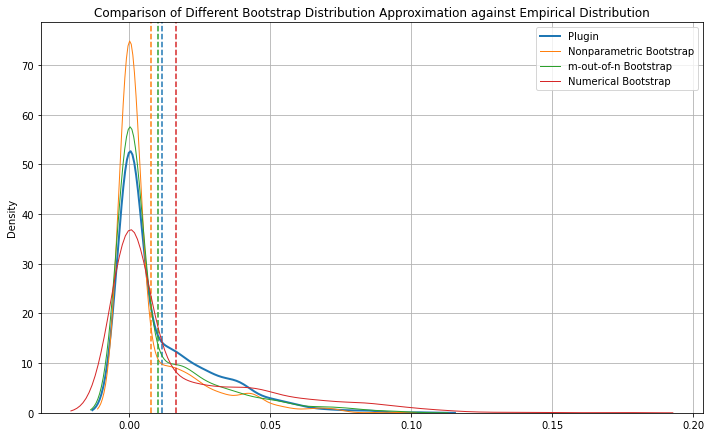

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# empirical distribution of plugin estimate
for idx, (name, dstn_arr) in enumerate(approx_dstn_dict.items()):
    linewidth = 2 if name == 'Plugin' else 1
    sns.kdeplot(dstn_arr, color=f'C{idx}', label=name, ax=ax, linewidth=linewidth)
    ax.axvline(dstn_arr.mean(), color=f'C{idx}', linestyle='--')


plt.title('Comparison of Different Bootstrap Distribution Approximation against Empirical Distribution')
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

### Bias correction

In [105]:
def bias_correction_single_experiment(dgp_params: dict, estimator: callable, estimator_params: dict) -> dict:
    # sample
    sample_arr = dgp_params['variable'].sample(dgp_params['sample_size'])

    # initialize results dictionary
    results_dict = {}

    # estimation
    for name, estimator_dict in estimator_params.items():
        if name == 'Plugin':
            plugin_est = estimator_dict['estimator'](sample_arr)
            results_dict[name] = plugin_est
        else:
            boot_dstn = estimator_dict['estimator'](sample_arr, **estimator_dict['params'], estimator=estimator)
            results_dict[f'{name}_est'] = 2 * plugin_est - boot_dstn.mean()

    return results_dict

In [106]:
bias_correction_single_experiment(dgp_params, estimator, estimator_params)

{'Plugin': 0.029357147174696684,
 'Nonparametric Bootstrap_est': 0.025784833117332255,
 'm-out-of-n Bootstrap_est': 0.014706472983527029,
 'Numerical Bootstrap_est': 0.022104583443535462}

In [107]:
def bias_correction_repeated_experiments(
    dgp_params: dict, estimator: callable, estimator_params: dict, n_experiments: int
) -> list:
    return [
        bias_correction_single_experiment(dgp_params, estimator, estimator_params) for _ in tqdm(range(n_experiments))
    ]

In [108]:
bias_correction_records = bias_correction_repeated_experiments(dgp_params, estimator, estimator_params, 1000)

  2%|▏         | 22/1000 [00:05<04:28,  3.64it/s]/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_14496/1596440593.py:40: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  ks_stat, _ = ks_2samp(prev_dstn, current_dstn)
100%|██████████| 1000/1000 [04:34<00:00,  3.65it/s]


True Value: 0.0000
Plugin: 0.0124 (0.0006)
Nonparametric Bootstrap_est: 0.0071 (0.0006)
m-out-of-n Bootstrap_est: 0.0007 (0.0007)
Numerical Bootstrap_est: 0.0003 (0.0007)


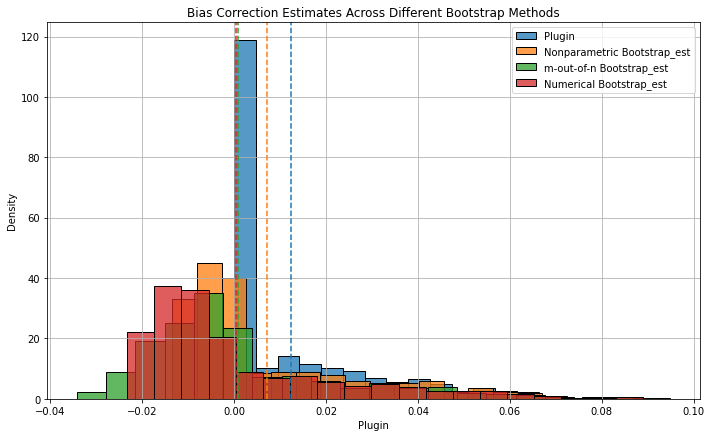

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_data = pd.DataFrame.from_records(bias_correction_records)

print(f'True Value: {func(dgp_params["variable"].mean):.4f}')
for col in viz_data.columns:
    print(f'{col}: {viz_data[col].mean():.4f} ({viz_data[col].std() / np.sqrt(viz_data.shape[0]):.4f})')

for idx, col in enumerate(viz_data.columns):
    sns.histplot(viz_data[col], bins=20, stat='density', ax=ax, color=f'C{idx}', label=col)
    ax.axvline(viz_data[col].mean(), linestyle='--', color=f'C{idx}')

del viz_data

plt.title('Bias Correction Estimates Across Different Bootstrap Methods')
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()